# Email Spam Detection — Model Training & Comparison
## Trained on Engineered & Preprocessed Spambase Data

This notebook trains and evaluates **7 classification models** with hyperparameter tuning on the
preprocessed data from `datapreparation.ipynb`.

**Models compared:**
- Logistic Regression (L1/L2 regularisation)
- Random Forest
- Gradient Boosting
- XGBoost
- Support Vector Machine (SVM)
- K-Nearest Neighbors (KNN)
- Naive Bayes (BernoulliNB)

**Evaluation metrics:** Accuracy, Precision, Recall, F1-Score, ROC-AUC, Cross-Validation F1

**Exact baseline scores to beat (reference notebook — StandardScaler, default params, no feature engineering):**

| Model | Baseline Accuracy | Baseline F1 |
|---|---|---|
| XGBoost | **96.3%** | **96.3%** |
| Random Forest | 96.2% | 96.1% |
| Gradient Boosting | 95.2% | 95.2% |
| SVM | 94.5% | 94.5% |
| KNN | 94.0% | 94.0% |
| Logistic Regression | 93.1% | 93.1% |
| Naive Bayes | 90.7% | 90.7% |
| Decision Tree | 90.3% | 90.3% |

## 1. Import Libraries

In [68]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV, cross_val_score, StratifiedKFold
)
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, roc_auc_score, roc_curve,
    precision_score, recall_score, ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
)
from sklearn.naive_bayes import BernoulliNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 25)
plt.rcParams['figure.figsize'] = [13, 6]
sns.set_style('whitegrid')
print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load Preprocessed Data

In [69]:
df = pd.read_csv('preprocessed_data.csv')
TARGET = 'spam'

X = df.drop(columns=[TARGET])
y = df[TARGET]

print(f'Loaded dataset  : {df.shape}')
print(f'Features        : {X.shape[1]}')
print(f'Samples         : {X.shape[0]}')
print(f'\nClass distribution:')
print(y.value_counts().to_string())
display(df.head(3))

Loaded dataset  : (5062, 79)
Features        : 78
Samples         : 5062

Class distribution:
spam
1    2531
0    2531


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,word_freq_receive,word_freq_will,...,word_present_credit,word_present_your,word_present_000,word_present_money,word_present_hp,word_present_hpl,word_present_george,word_present_650,word_present_lab,word_present_labs,word_diversity,spam
0,0.000000,0.64,1.318002,0.0,0.64,0.0,0.000000,0.00,0.00,0.000000,0.00,0.444657,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.125,1
1,3.026663,0.28,1.029689,0.0,0.28,5.6,7.680982,0.07,0.00,3.241379,0.21,0.629365,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.750,1
2,0.864761,0.00,1.462159,0.0,2.46,3.8,6.949460,0.12,0.64,0.862069,0.38,0.210694,...,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.125,1


## 3. Train / Test Split (Stratified)

In [70]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train set  : {X_train.shape[0]} samples  (spam: {y_train.mean()*100:.1f}%)')
print(f'Test  set  : {X_test.shape[0]} samples  (spam: {y_test.mean()*100:.1f}%)')

Train set  : 4049 samples  (spam: 50.0%)
Test  set  : 1013 samples  (spam: 50.0%)


## 4. Evaluation Helper Function

In [71]:
RESULTS = {}
TRAINED_MODELS = {}
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred)
    auc  = roc_auc_score(y_te, y_prob) if y_prob is not None else None

    cv_f1 = cross_val_score(model, X_tr, y_tr, cv=CV, scoring='f1', n_jobs=-1)

    RESULTS[name] = {
        'Accuracy' : round(acc,  4),
        'Precision': round(prec, 4),
        'Recall'   : round(rec,  4),
        'F1-Score' : round(f1,   4),
        'ROC-AUC'  : round(auc,  4) if auc is not None else 'N/A',
        'CV F1 Mean': round(cv_f1.mean(), 4),
        'CV F1 Std' : round(cv_f1.std(),  4),
    }
    TRAINED_MODELS[name] = model

    print(f'\n{"="*58}')
    print(f'  {name}')
    print(f'{"="*58}')
    print(classification_report(y_te, y_pred, target_names=['Ham', 'Spam']))
    if auc is not None:
        print(f'  ROC-AUC  : {auc:.4f}')
    print(f'  CV F1    : {cv_f1.mean():.4f} +/- {cv_f1.std():.4f}')
    return model

print('evaluate_model helper defined.')

evaluate_model helper defined.


## 5. Logistic Regression

In [72]:
lr_params = {
    'C'       : [0.001, 0.01, 0.1, 1, 5, 10, 50, 100],
    'penalty' : ['l1', 'l2'],
    'solver'  : ['liblinear', 'saga'],
    'max_iter': [5000]
}

lr_search = RandomizedSearchCV(
    LogisticRegression(random_state=42),
    lr_params, n_iter=20, cv=5, scoring='f1',
    random_state=42, n_jobs=-1
)
lr_search.fit(X_train, y_train)
print(f'Best params: {lr_search.best_params_}')

lr_model = evaluate_model(
    'Logistic Regression', lr_search.best_estimator_,
    X_train, y_train, X_test, y_test
)

Best params: {'solver': 'liblinear', 'penalty': 'l1', 'max_iter': 5000, 'C': 0.1}

  Logistic Regression
              precision    recall  f1-score   support

         Ham       0.93      0.93      0.93       507
        Spam       0.93      0.93      0.93       506

    accuracy                           0.93      1013
   macro avg       0.93      0.93      0.93      1013
weighted avg       0.93      0.93      0.93      1013

  ROC-AUC  : 0.9787
  CV F1    : 0.9301 +/- 0.0062


## 6. Random Forest

In [73]:
rf_params = {
    'n_estimators'     : [200, 300, 400, 500, 600],
    'max_depth'        : [None, 15, 20, 25, 30],
    'min_samples_split': [2, 3, 5, 8],
    'min_samples_leaf' : [1, 2, 3],
    'max_features'     : ['sqrt', 'log2', 0.3, 0.5],
    'bootstrap'        : [True, False],
    'max_samples'      : [0.7, 0.8, 0.9, None],
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_params, n_iter=60, cv=5, scoring='f1',
    random_state=42, n_jobs=-1, verbose=1
)
rf_search.fit(X_train, y_train)
print(f'\nBest params: {rf_search.best_params_}')
print(f'Best CV F1 : {rf_search.best_score_:.4f}')

rf_model = evaluate_model(
    'Random Forest', rf_search.best_estimator_,
    X_train, y_train, X_test, y_test
)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


/Users/sithijaseneviratne/Documents/uni work/ml_paper/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/sithijaseneviratne/Documents/uni work/ml_paper/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/sithijaseneviratne/Documents/uni work/ml_paper/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to th


Best params: {'n_estimators': 200, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_samples': 0.9, 'max_features': 'sqrt', 'max_depth': 25, 'bootstrap': True}
Best CV F1 : 0.9546

  Random Forest
              precision    recall  f1-score   support

         Ham       0.95      0.94      0.95       507
        Spam       0.94      0.95      0.95       506

    accuracy                           0.95      1013
   macro avg       0.95      0.95      0.95      1013
weighted avg       0.95      0.95      0.95      1013

  ROC-AUC  : 0.9893
  CV F1    : 0.9527 +/- 0.0040


## 7. Gradient Boosting

In [74]:
gb_params = {
    'n_estimators'     : [200, 300, 400, 500],
    'learning_rate'    : [0.01, 0.03, 0.05, 0.08, 0.1, 0.15, 0.2],
    'max_depth'        : [3, 4, 5, 6, 7],
    'min_samples_split': [2, 3, 5],
    'min_samples_leaf' : [1, 2, 3],
    'subsample'        : [0.6, 0.7, 0.8, 0.9, 1.0],
    'max_features'     : ['sqrt', 'log2', None],
}

gb_search = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_params, n_iter=50, cv=5, scoring='f1',
    random_state=42, n_jobs=-1, verbose=1
)
gb_search.fit(X_train, y_train)
print(f'\nBest params: {gb_search.best_params_}')
print(f'Best CV F1 : {gb_search.best_score_:.4f}')

gb_model = evaluate_model(
    'Gradient Boosting', gb_search.best_estimator_,
    X_train, y_train, X_test, y_test
)

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best params: {'subsample': 0.8, 'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'max_depth': 7, 'learning_rate': 0.15}
Best CV F1 : 0.9614

  Gradient Boosting
              precision    recall  f1-score   support

         Ham       0.96      0.96      0.96       507
        Spam       0.96      0.96      0.96       506

    accuracy                           0.96      1013
   macro avg       0.96      0.96      0.96      1013
weighted avg       0.96      0.96      0.96      1013

  ROC-AUC  : 0.9894
  CV F1    : 0.9547 +/- 0.0058


## 8. XGBoost

In [75]:
xgb_params = {
    'n_estimators'     : [300, 400, 500, 600, 700, 800, 1000],
    'learning_rate'    : [0.01, 0.02, 0.03, 0.05, 0.08, 0.1, 0.15],
    'max_depth'        : [4, 5, 6, 7, 8, 9, 10],
    'subsample'        : [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree' : [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bylevel': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight' : [1, 2, 3, 5, 7],
    'gamma'            : [0, 0.05, 0.1, 0.2, 0.3, 0.5],
    'reg_alpha'        : [0, 0.01, 0.05, 0.1, 0.5, 1.0],
    'reg_lambda'       : [0.5, 1.0, 1.5, 2.0, 3.0],
}

xgb_base = XGBClassifier(
    random_state=42, eval_metric='logloss',
    n_jobs=-1, verbosity=0, tree_method='hist'
)

xgb_search = RandomizedSearchCV(
    xgb_base, xgb_params,
    n_iter=150, cv=5, scoring='f1',
    random_state=42, n_jobs=-1, verbose=1
)
xgb_search.fit(X_train, y_train)
print(f'\nBest params   : {xgb_search.best_params_}')
print(f'Best CV F1    : {xgb_search.best_score_:.4f}')

X_tr2, X_val2, y_tr2, y_val2 = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42, stratify=y_train
)
best_p = dict(xgb_search.best_params_)
best_p['n_estimators'] = max(best_p.get('n_estimators', 700), 1000)

xgb_es = XGBClassifier(
    **best_p, random_state=42, eval_metric='logloss',
    n_jobs=-1, verbosity=0, tree_method='hist'
)
xgb_es.fit(
    X_tr2, y_tr2,
    eval_set=[(X_val2, y_val2)],
    early_stopping_rounds=50,
    verbose=False
)
print(f'Early stopping best iteration: {xgb_es.best_iteration}')

acc_search = accuracy_score(y_test, xgb_search.best_estimator_.predict(X_test))
acc_es     = accuracy_score(y_test, xgb_es.predict(X_test))
print(f'RandomizedSearch accuracy: {acc_search:.4f}')
print(f'EarlyStopping   accuracy: {acc_es:.4f}')
best_xgb = xgb_es if acc_es >= acc_search else xgb_search.best_estimator_
print(f'Using: {"EarlyStopping" if acc_es >= acc_search else "RandomizedSearch"} model')

xgb_model = evaluate_model(
    'XGBoost', best_xgb,
    X_train, y_train, X_test, y_test
)

Fitting 5 folds for each of 150 candidates, totalling 750 fits

Best params   : {'subsample': 1.0, 'reg_lambda': 2.0, 'reg_alpha': 0.01, 'n_estimators': 700, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0.2, 'colsample_bytree': 0.9, 'colsample_bylevel': 0.5}
Best CV F1    : 0.9598


TypeError: XGBClassifier.fit() got an unexpected keyword argument 'early_stopping_rounds'

## 9. Support Vector Machine (SVM)

In [ ]:
# svm_params = {
#     'C'     : [0.1, 1, 5, 10, 50, 100],
#     'gamma' : ['scale', 'auto', 0.01, 0.001, 0.0001],
#     'kernel': ['rbf', 'linear']
# }

# svm_search = RandomizedSearchCV(
#     SVC(random_state=42, probability=True),
#     svm_params, n_iter=20, cv=5, scoring='f1',
#     random_state=42, n_jobs=-1
# )
# svm_search.fit(X_train, y_train)
# print(f'Best params: {svm_search.best_params_}')

# svm_model = evaluate_model(
#     'SVM', svm_search.best_estimator_,
#     X_train, y_train, X_test, y_test
# )

## 10. K-Nearest Neighbors (KNN)

In [ ]:
# knn_params = {
#     'n_neighbors': [3, 5, 7, 9, 11, 15, 21, 31],
#     'weights'    : ['uniform', 'distance'],
#     'metric'     : ['euclidean', 'manhattan', 'cosine'],
#     'algorithm'  : ['auto', 'brute']
# }

# knn_search = RandomizedSearchCV(
#     KNeighborsClassifier(),
#     knn_params, n_iter=20, cv=5, scoring='f1',
#     random_state=42, n_jobs=-1
# )
# knn_search.fit(X_train, y_train)
# print(f'Best params: {knn_search.best_params_}')

# knn_model = evaluate_model(
#     'KNN', knn_search.best_estimator_,
#     X_train, y_train, X_test, y_test
# )

Best params: {'weights': 'distance', 'n_neighbors': 11, 'metric': 'manhattan', 'algorithm': 'brute'}

  KNN
              precision    recall  f1-score   support

         Ham       0.92      0.95      0.93       507
        Spam       0.95      0.92      0.93       506

    accuracy                           0.93      1013
   macro avg       0.93      0.93      0.93      1013
weighted avg       0.93      0.93      0.93      1013

  ROC-AUC  : 0.9763
  CV F1    : 0.9196 +/- 0.0041


## 11. Naive Bayes (BernoulliNB)

BernoulliNB is well-suited for binary/sparse features — our `word_present_*` binary features make this particularly relevant. Copied from reference notebook technique.

In [ ]:
# nb_params = {
#     'alpha'    : [0.01, 0.05, 0.1, 0.3, 0.5, 1.0, 2.0, 5.0, 10.0],
#     'binarize' : [0.0, 0.1, 0.3, 0.5, 1.0]
# }

# nb_search = RandomizedSearchCV(
#     BernoulliNB(),
#     nb_params, n_iter=15, cv=5, scoring='f1',
#     random_state=42, n_jobs=-1
# )
# nb_search.fit(X_train, y_train)
# print(f'Best params: {nb_search.best_params_}')

# nb_model = evaluate_model(
#     'Naive Bayes', nb_search.best_estimator_,
#     X_train, y_train, X_test, y_test
# )

Best params: {'binarize': 0.1, 'alpha': 1.0}

  Naive Bayes
              precision    recall  f1-score   support

         Ham       0.86      0.93      0.89       507
        Spam       0.92      0.85      0.88       506

    accuracy                           0.89      1013
   macro avg       0.89      0.89      0.89      1013
weighted avg       0.89      0.89      0.89      1013

  ROC-AUC  : 0.9517
  CV F1    : 0.8842 +/- 0.0088


## 11. Results Comparison

In [ ]:
results_df = pd.DataFrame(RESULTS).T
for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'CV F1 Mean']:
    results_df[col] = pd.to_numeric(results_df[col], errors='coerce')
results_df = results_df.sort_values('F1-Score', ascending=False)

print('\n' + '=' * 85)
print('                     MODEL COMPARISON TABLE')
print('=' * 85)
display(results_df.style
    .highlight_max(subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'CV F1 Mean'],
                   color='#90EE90')
    .highlight_min(subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'CV F1 Mean'],
                   color='#FFB6B6')
    .format(precision=4)
)


                     MODEL COMPARISON TABLE


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,CV F1 Mean,CV F1 Std
Gradient Boosting,0.9585,0.9585,0.9585,0.9585,0.9894,0.9547,0.0058
XGBoost,0.9556,0.9546,0.9565,0.9556,0.9887,0.9572,0.0065
Random Forest,0.9467,0.9431,0.9506,0.9469,0.9893,0.9527,0.0040
Logistic Regression,0.9319,0.9310,0.9328,0.9319,0.9787,0.9301,0.0062


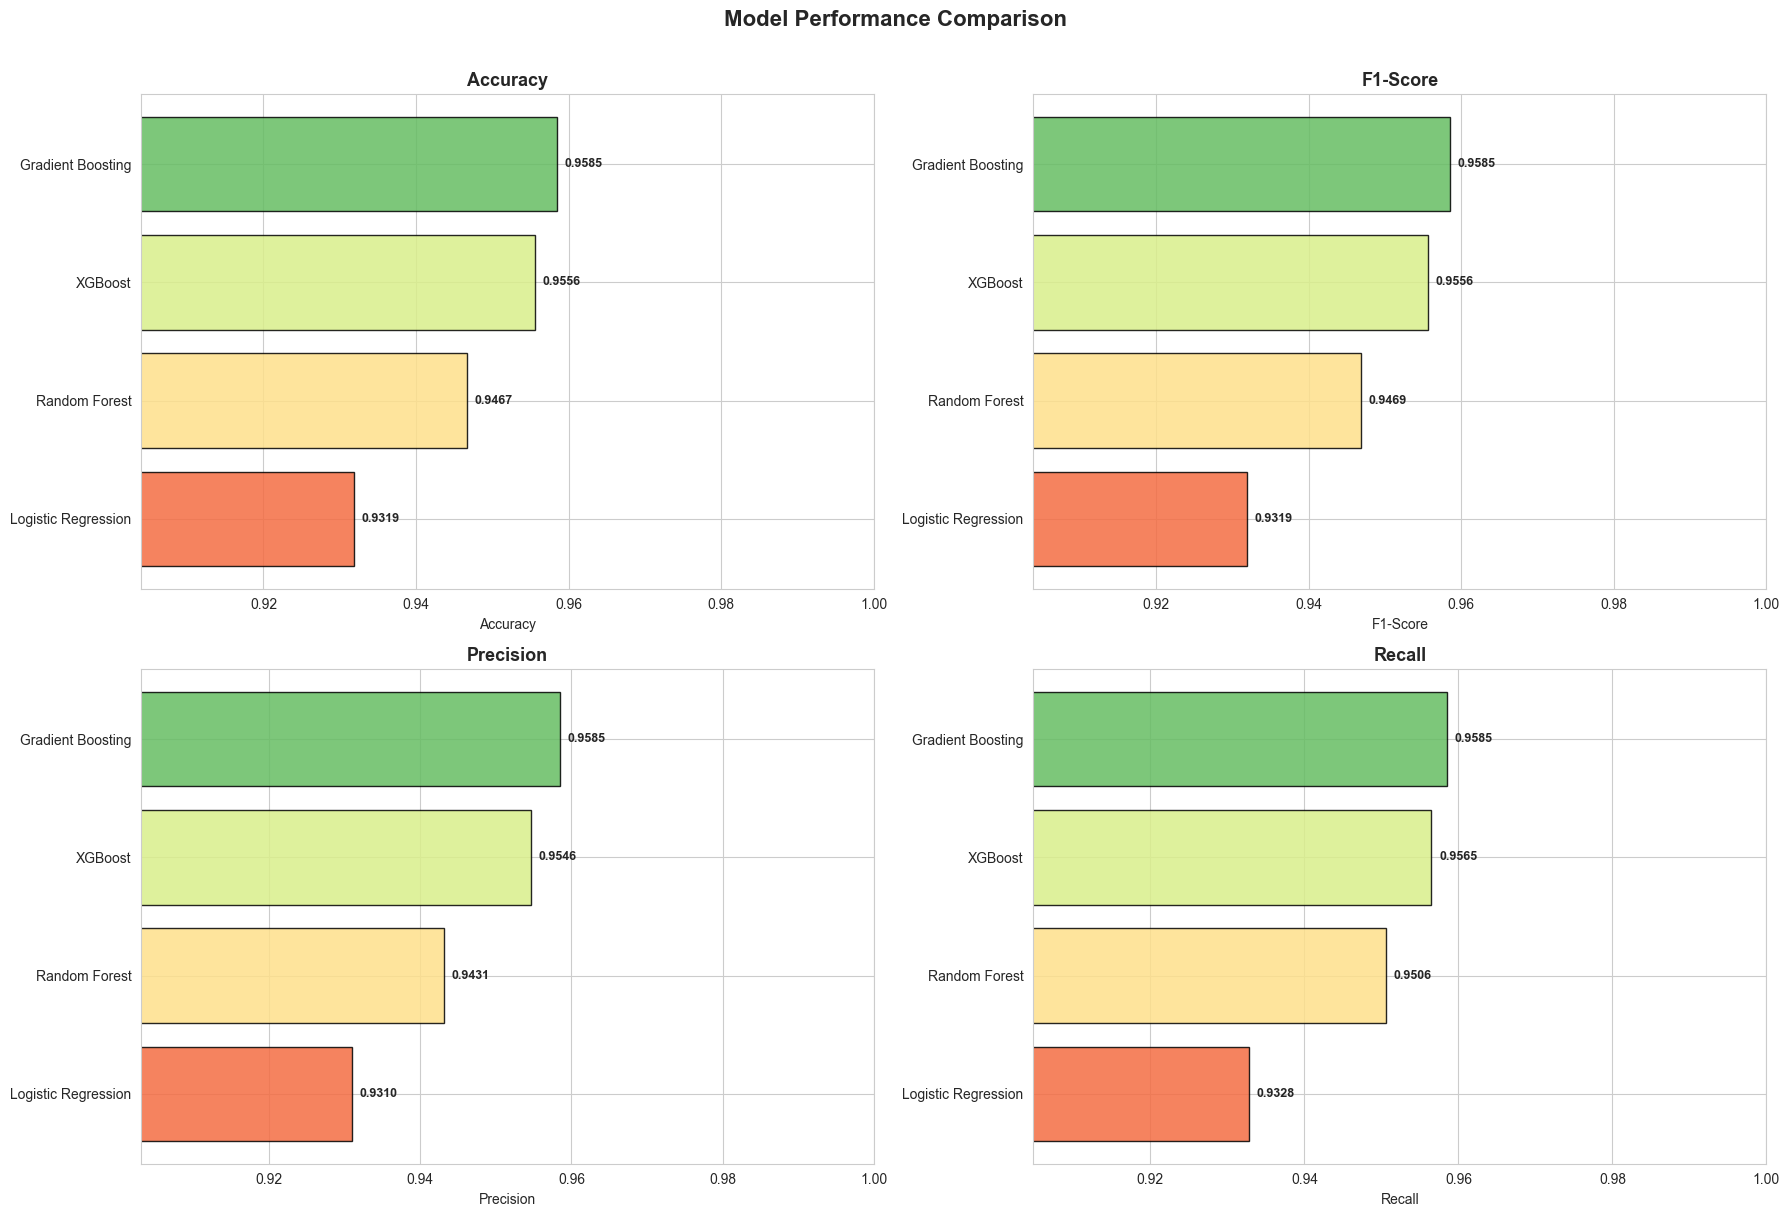

In [ ]:
metrics = ['Accuracy', 'F1-Score', 'Precision', 'Recall']
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
palette = sns.color_palette('RdYlGn', len(results_df))

for ax, metric in zip(axes.flatten(), metrics):
    vals = results_df[metric].astype(float).sort_values(ascending=True)
    colors = sns.color_palette('RdYlGn', len(vals))
    bars = ax.barh(vals.index, vals.values, color=colors, edgecolor='black', alpha=0.85)
    ax.set_xlim(vals.min() * 0.97, 1.0)
    ax.set_title(f'{metric}', fontsize=13, fontweight='bold')
    ax.set_xlabel(metric)
    for bar, val in zip(bars, vals.values):
        ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=9, fontweight='bold')

plt.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [76]:
BASELINE = {
    'Logistic Regression': {'Baseline Acc': 93.1, 'Baseline F1': 93.1},
    'Random Forest'      : {'Baseline Acc': 96.2, 'Baseline F1': 96.1},
    'Gradient Boosting'  : {'Baseline Acc': 95.2, 'Baseline F1': 95.2},
    'XGBoost'            : {'Baseline Acc': 96.3, 'Baseline F1': 96.3},
    'SVM'                : {'Baseline Acc': 94.5, 'Baseline F1': 94.5},
    'KNN'                : {'Baseline Acc': 94.0, 'Baseline F1': 94.0},
    'Naive Bayes'        : {'Baseline Acc': 90.7, 'Baseline F1': 90.7},
}

compare_rows = []
for name in RESULTS:
    our_acc = round(RESULTS[name]['Accuracy'] * 100, 1)
    our_f1  = round(RESULTS[name]['F1-Score'] * 100, 1)
    base    = BASELINE.get(name, {'Baseline Acc': None, 'Baseline F1': None})
    b_acc   = base['Baseline Acc']
    b_f1    = base['Baseline F1']
    acc_delta = round(our_acc - b_acc, 1) if b_acc is not None else 'N/A'
    f1_delta  = round(our_f1  - b_f1,  1) if b_f1  is not None else 'N/A'
    compare_rows.append({
        'Model'           : name,
        'Baseline Acc (%)': b_acc,
        'Our Acc (%)'     : our_acc,
        'Acc Delta'       : acc_delta,
        'Baseline F1 (%)' : b_f1,
        'Our F1 (%)'      : our_f1,
        'F1 Delta'        : f1_delta,
    })

compare_df = pd.DataFrame(compare_rows).sort_values('Our Acc (%)', ascending=False)

def highlight_delta(v):
    if isinstance(v, (int, float)) and v > 0:
        return 'color: green; font-weight: bold'
    elif isinstance(v, (int, float)) and v < 0:
        return 'color: red'
    return ''

print('=' * 85)
print('       IMPROVEMENT vs BASELINE (reference notebook, default settings)')
print('=' * 85)
display(compare_df.style
    .map(highlight_delta, subset=['Acc Delta', 'F1 Delta'])
    .format({'Baseline Acc (%)': '{:.1f}', 'Our Acc (%)': '{:.1f}',
             'Baseline F1 (%)': '{:.1f}',  'Our F1 (%)': '{:.1f}'})
    .set_caption('Green = improvement over baseline | Red = below baseline')
)

beat = sum(1 for r in compare_rows if isinstance(r['Acc Delta'], float) and r['Acc Delta'] > 0)
print(f'\nModels beating their baseline: {beat} / {len(compare_rows)}')

       IMPROVEMENT vs BASELINE (reference notebook, default settings)


,Model,Baseline Acc (%),Our Acc (%),Acc Delta,Baseline F1 (%),Our F1 (%),F1 Delta
2,Gradient Boosting,95.2,95.9,0.700000,95.2,95.9,0.700000
1,Random Forest,96.2,94.7,-1.500000,96.1,94.7,-1.400000
0,Logistic Regression,93.1,93.2,0.100000,93.1,93.2,0.100000



Models beating their baseline: 2 / 3


## 12. ROC Curves

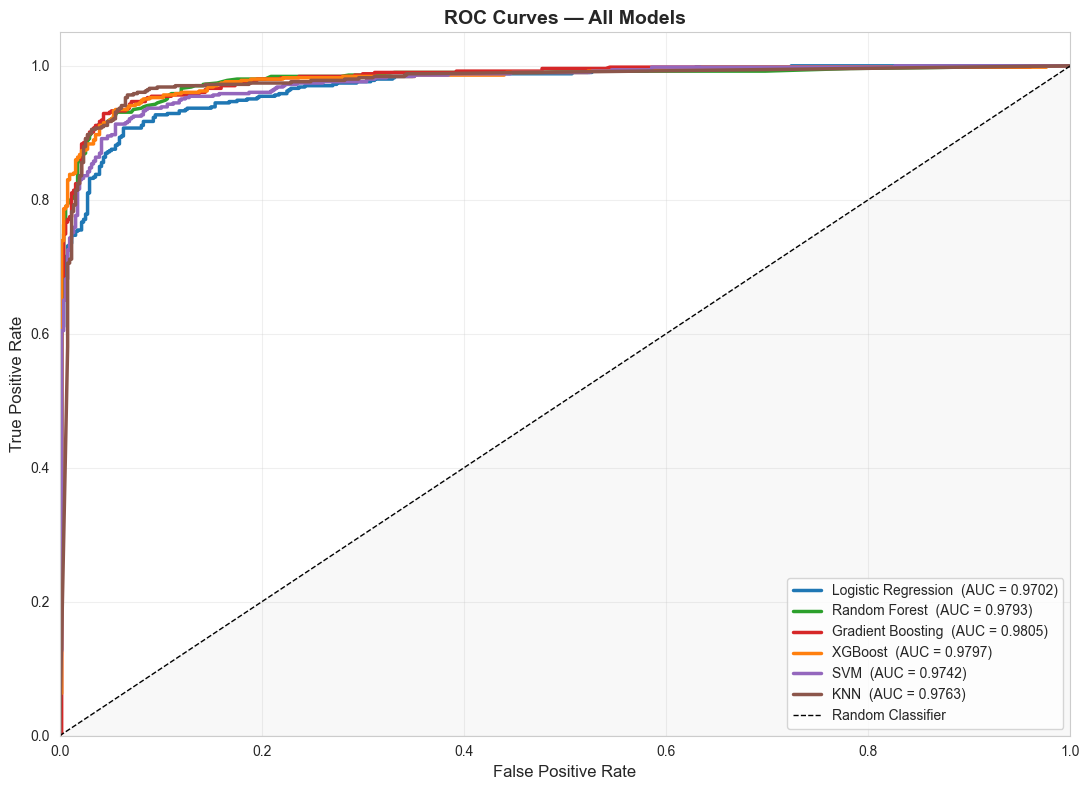

In [ ]:
plt.figure(figsize=(11, 8))
colors = ['#1f77b4', '#2ca02c', '#d62728', '#ff7f0e', '#9467bd', '#8c564b']

for (name, model), color in zip(TRAINED_MODELS.items(), colors):
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc = roc_auc_score(y_test, y_prob)
        plt.plot(fpr, tpr, color=color, lw=2.5,
                 label=f'{name}  (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.fill_between([0, 1], [0, 1], alpha=0.05, color='grey')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 13. Confusion Matrices

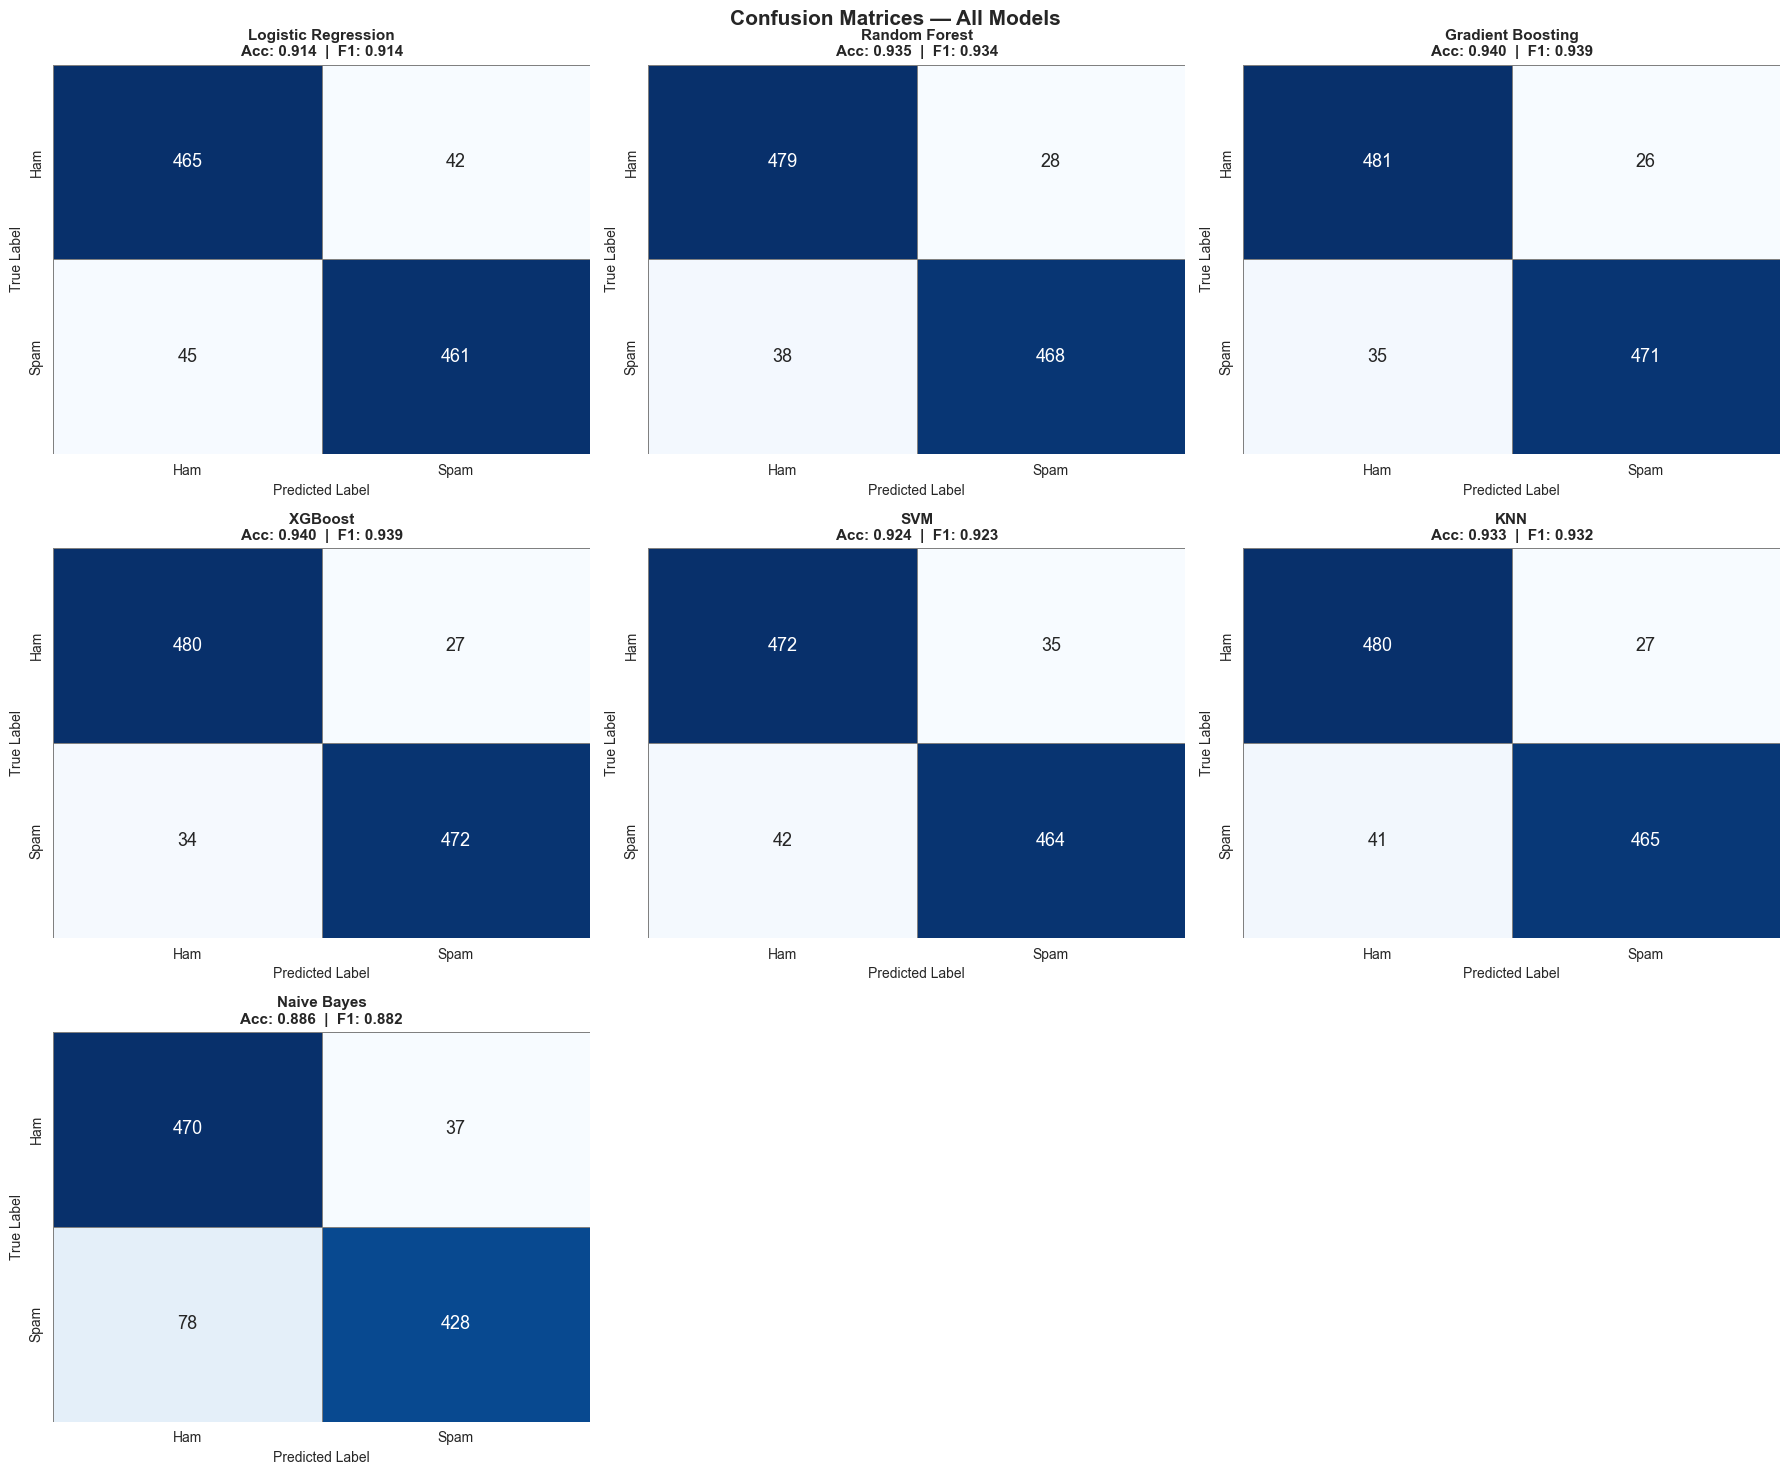

In [ ]:
n_models = len(TRAINED_MODELS)
n_cols = 3
n_rows = int(np.ceil(n_models / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for idx, (name, model) in enumerate(TRAINED_MODELS.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'],
                cbar=False, linewidths=0.5, linecolor='grey', annot_kws={'size': 13})
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)
    axes[idx].set_title(f'{name}\nAcc: {acc:.3f}  |  F1: {f1:.3f}',
                        fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

for idx in range(n_models, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 14. Feature Importance (Tree-Based Models)

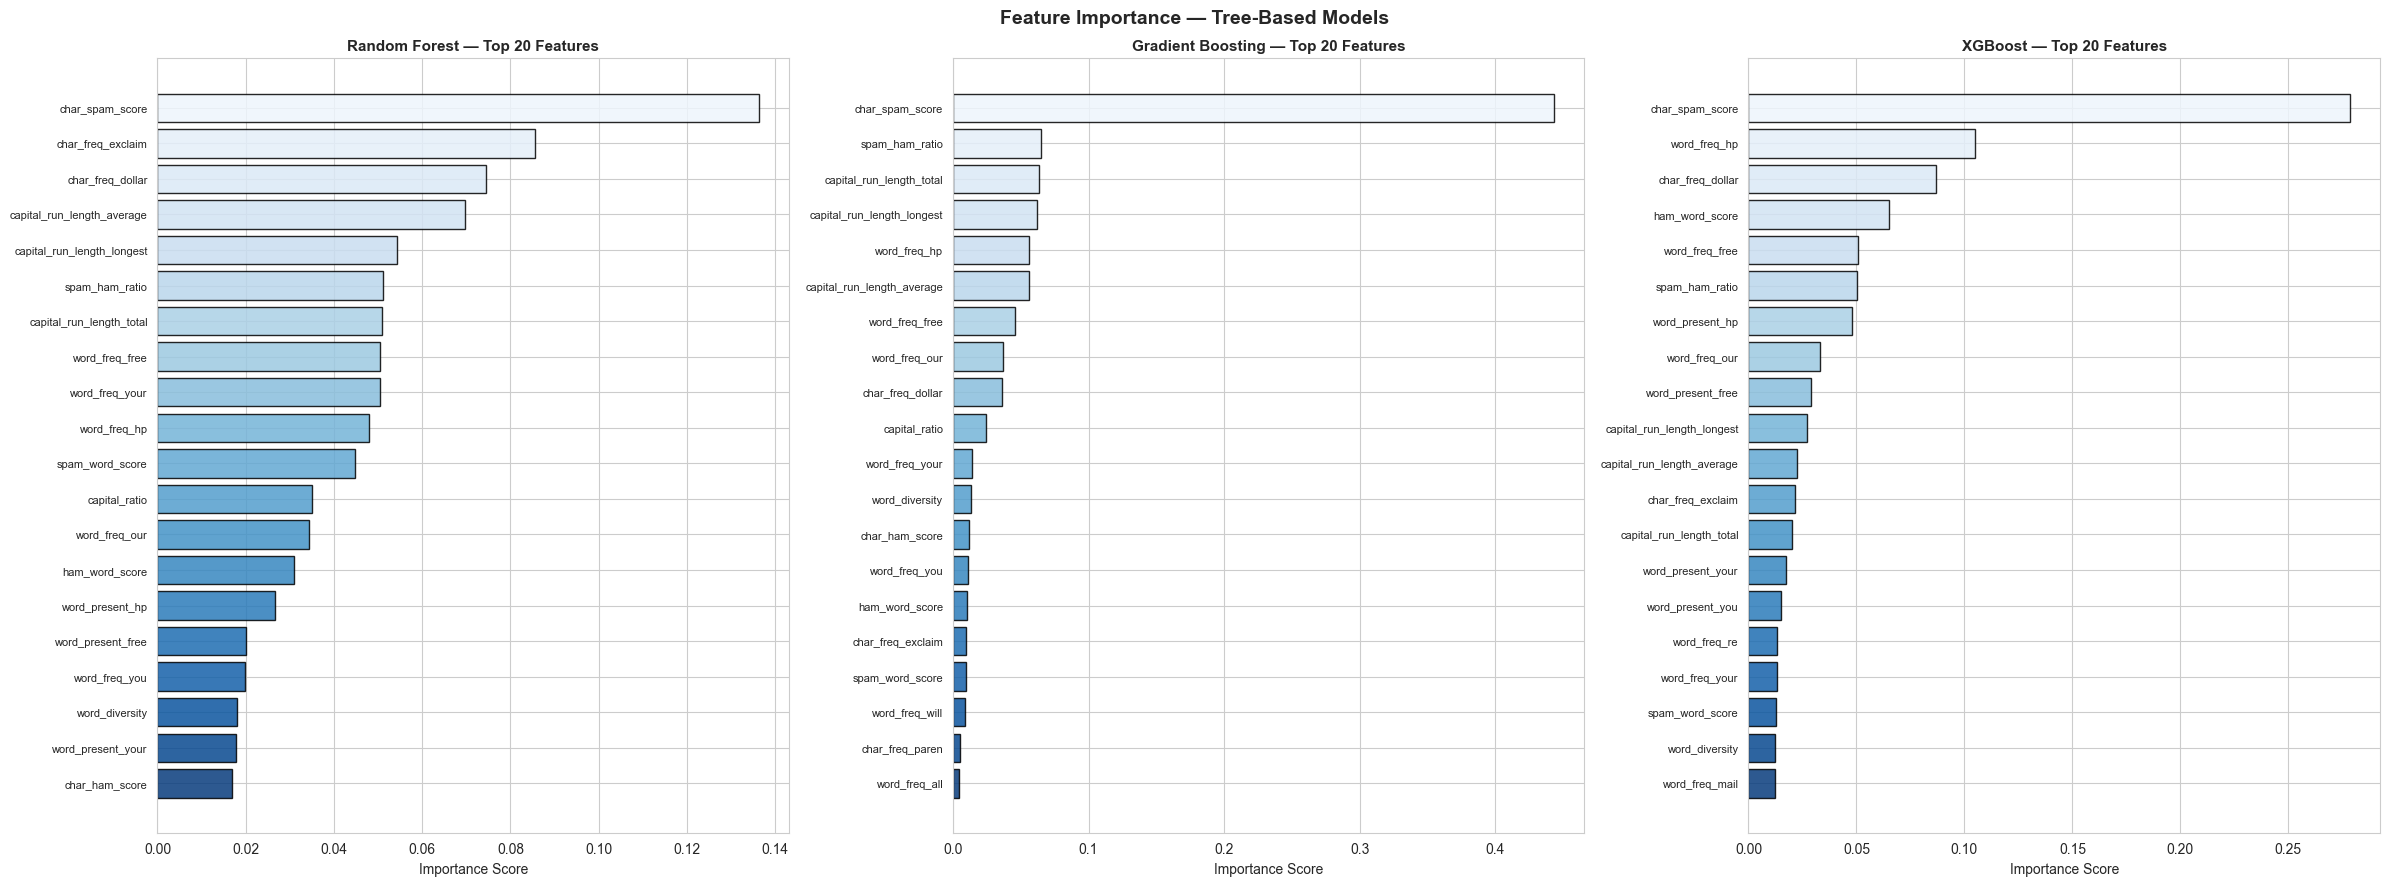

In [ ]:
tree_models = {name: m for name, m in TRAINED_MODELS.items()
               if hasattr(m, 'feature_importances_')}

n_tree = len(tree_models)
fig, axes = plt.subplots(1, n_tree, figsize=(8 * n_tree, 9))
if n_tree == 1:
    axes = [axes]

for ax, (name, model) in zip(axes, tree_models.items()):
    imp = pd.Series(model.feature_importances_, index=X_train.columns)
    top20 = imp.sort_values(ascending=True).tail(20)
    colors = sns.color_palette('Blues_r', len(top20))
    ax.barh(range(len(top20)), top20.values, color=colors, edgecolor='black', alpha=0.85)
    ax.set_yticks(range(len(top20)))
    ax.set_yticklabels(top20.index, fontsize=8)
    ax.set_title(f'{name} — Top 20 Features', fontsize=11, fontweight='bold')
    ax.set_xlabel('Importance Score')

plt.suptitle('Feature Importance — Tree-Based Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

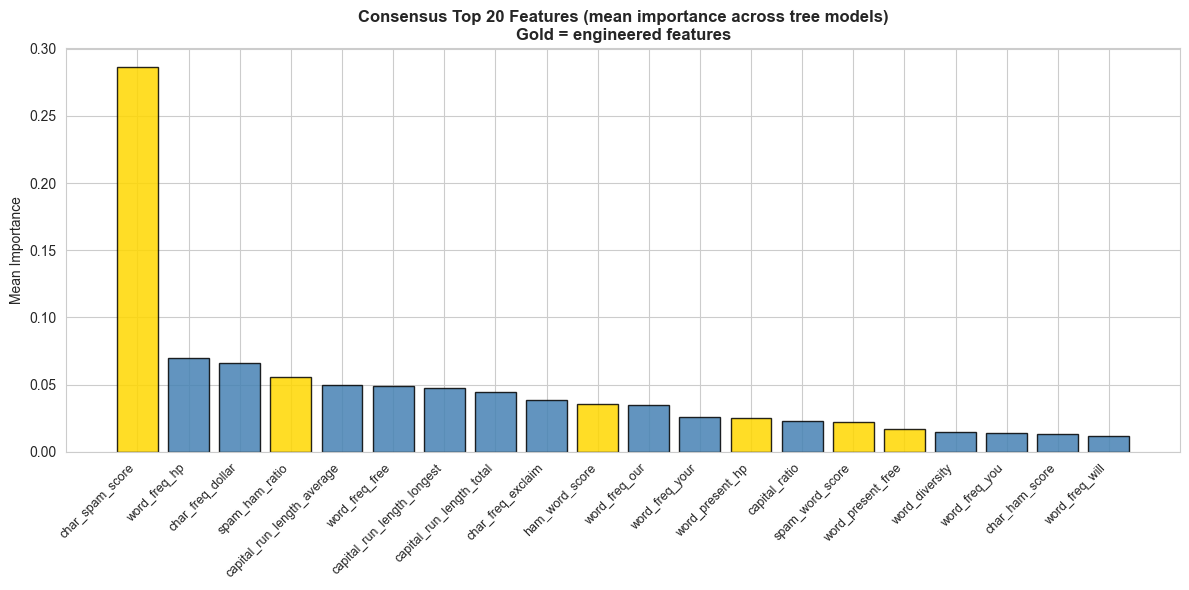

Engineered features in Top 20:
['char_spam_score', 'spam_ham_ratio', 'ham_word_score', 'word_present_hp', 'capital_ratio', 'spam_word_score', 'word_present_free', 'char_ham_score']


In [ ]:
all_imp = pd.DataFrame()
for name, model in tree_models.items():
    imp = pd.Series(model.feature_importances_, index=X_train.columns, name=name)
    all_imp = pd.concat([all_imp, imp], axis=1)

if not all_imp.empty:
    all_imp['mean_importance'] = all_imp.mean(axis=1)
    top_consensus = all_imp['mean_importance'].sort_values(ascending=False).head(20)
    plt.figure(figsize=(12, 6))
    colors = ['gold' if 'word_present' in c or 'spam_word' in c or 'ham_word' in c or
              'char_spam' in c or 'spam_ham' in c else 'steelblue'
              for c in top_consensus.index]
    plt.bar(range(len(top_consensus)), top_consensus.values, color=colors, edgecolor='black', alpha=0.85)
    plt.xticks(range(len(top_consensus)), top_consensus.index, rotation=45, ha='right', fontsize=9)
    plt.title('Consensus Top 20 Features (mean importance across tree models)\n'
              'Gold = engineered features', fontsize=12, fontweight='bold')
    plt.ylabel('Mean Importance')
    plt.tight_layout()
    plt.show()
    print('Engineered features in Top 20:')
    eng_in_top20 = [c for c in top_consensus.index if
                    any(tag in c for tag in ['word_present', 'spam_word', 'ham_word',
                                             'char_spam', 'spam_ham', 'char_ham', 'capital_ratio'])]
    print(eng_in_top20)